# Análise Exploratória dos dados para X-Health

- Autora: Natália de Faria

## Importando bibliotecas

In [1]:
#adicionando retorno no diretório ao caminho
import sys
sys.path.append('../')

#ignorar warnings 
import warnings
warnings.filterwarnings('ignore')

#adicionando arquivos locais
from src.globals import *
from src.eda import *
from src.plots import *
from src.auxiliar_xhealth import *

2025-02-03 16:25:45.421 | INFO     | src.globals:<module>:7 - PROJ_ROOT path is C:\Users\Natalia\OneDrive\Documentos\PROJETOS\x_health


In [2]:


import pandas as pd 
import numpy as np

import pytz
import time
import gc

from loguru import logger
import csv
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from scipy import stats

In [3]:
#mostrar todas as colunas
pd.set_option('display.max_columns',None)

### Importando base

In [4]:
#importando a base do arquivo externo
nome_base = f'{EXTERNAL_DATA_DIR}/dataset_2021-5-26-10-14.csv'
df = pd.read_csv(nome_base, sep = '\t' ,encoding = 'utf-8')
logger.info(f'Base importada com tamanho: {len(df)}')

2025-02-03 16:25:48.929 | INFO     | __main__:<module>:4 - Base importada com tamanho: 117273


In [5]:
df.head(3)

,default_3months,ioi_36months,ioi_3months,valor_por_vencer,valor_vencido,valor_quitado,quant_protestos,valor_protestos,quant_acao_judicial,acao_judicial_valor,participacao_falencia_valor,dividas_vencidas_valor,dividas_vencidas_qtd,falencia_concordata_qtd,tipo_sociedade,opcao_tributaria,atividade_principal,forma_pagamento,valor_total_pedido,month,year,default
0,0,58.000000,18.236092,0.00,0.0,242100.70,0,0.0,0,0.0,0.0,0.0,0,0,empresario (individual),simples nacional,papelaria,30/60/90,34665.674938,6,2019,0
1,1,16.052632,7.500000,224132.85,0.0,4960846.21,0,0.0,0,0.0,0.0,0.0,0,0,sociedade empresaria limitada,missing,com de equipamentos de informatica,30/60/90,7134.489373,10,2018,0
2,0,13.250000,3.904762,513043.83,0.0,158631.93,1,1800.0,0,0.0,0.0,0.0,0,0,sociedade empresaria limitada,simples nacional,servicos de vigilancia e guarda,missing,72653.621143,4,2018,0


## Setando variáveis e calculando taxas de evento e não evento

In [6]:
# cores personalizadas 
COR_1 = "#b11a6c" #rosa
COR_2 = "#373d7a" #azul escuro
COR_3 = "#6e446b" #roxo escuro
COR_CINZA = "#999999"

In [7]:
#setando variáveis de interesse
flag_inadimplencia = df['default'].astype(int)
inadimplencia = 'default'

# taxa de inadimpência na base
taxa_inadimplencia = df[inadimplencia].mean()
evento = df[inadimplencia].sum()
nao_evento = len(df) - evento

logger.info(f'Avaliando conceito de inadimplencia na base:')
print(f'Na base temos {evento} casos de inadimplência e {nao_evento} de não eventos')
print(f'Esses valores geram uma taxa base de inadimplência de {taxa_inadimplencia}')
print(f'Então, um evento é uma inadimplência a cada {round(1/taxa_inadimplencia)} analisados, aproximadamente')

2025-02-03 16:25:49.016 | INFO     | __main__:<module>:10 - Avaliando conceito de inadimplencia na base:


Na base temos 19545 casos de inadimplência e 97728 de não eventos
Esses valores geram uma taxa base de inadimplência de 0.16666240311069044
Então, um evento é uma inadimplência a cada 6 analisados, aproximadamente


In [8]:
print('Media de inadimplência nos anos: ')
df.groupby('year')[inadimplencia].mean()

Media de inadimplência nos anos: 


year
2017    0.133478
2018    0.189044
2019    0.164740
Name: default, dtype: float64

In [9]:
# Definir colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

## Análise de missings na base

In [10]:
# Substituindo "missing" por NaN
df.replace("missing", pd.NA, inplace=True)

In [11]:
# Valores ausentes
total_missing = df.isna().sum()
percentual_missing = (total_missing / len(df)) * 100

In [12]:
# DF com os resultados
missing_df = pd.DataFrame({
    'Coluna': df.columns,
    'Valores Faltantes': percentual_missing.values,
    'Percentual (%)': percentual_missing.values
})

In [13]:
# Filtrar ausentes
missing_df = missing_df[missing_df["Valores Faltantes"] > 0]

In [14]:
# Exibir os resultados
print(missing_df.sort_values(by="Percentual (%)", ascending=False))

                 Coluna  Valores Faltantes  Percentual (%)
17      forma_pagamento          27.693501       27.693501
15     opcao_tributaria          15.625933       15.625933
14       tipo_sociedade           0.518448        0.518448
16  atividade_principal           0.504805        0.504805


- alto valor de missing em forma_pagamento, possíveis causas:
    - erro de preenchimento
    - clientes novos sem histórico
    - erro na coleta (ex: campo não obrigatório)
- To do:
    - analisar impacto na correlação com inadimplência

- alta taxa de missings em opção_tribuitaria, possíveis causas:
    - Falta de imformação na compra
    - problema de integração
- to do:
    - avaliar o comportamento de risco de quem tem missings
    - preencher com valores baseados nos dados (?)

## Análise de Outliers

### Z-Score

In [15]:
# Calcular o Z-Score
z_scores = np.abs(stats.zscore(df[numeric_cols]))

# Identificar outliers (Z > 3)
outliers_z = (z_scores > 3)

# Contar quantos outliers existem por coluna e transformar em Series
outliers_z_count = pd.Series(outliers_z.sum(axis=0), index=numeric_cols)

# Ordenar os resultados
print(outliers_z_count[outliers_z_count > 0].sort_values(ascending=False))

ioi_3months                2649
ioi_36months               2169
default_3months            1533
valor_quitado               974
valor_por_vencer            762
quant_acao_judicial         413
dividas_vencidas_qtd        235
valor_vencido               188
valor_total_pedido          171
valor_protestos             112
quant_protestos              69
acao_judicial_valor          58
falencia_concordata_qtd      54
dividas_vencidas_valor       11
dtype: int64


In [16]:
print(outliers_z_count[outliers_z_count > 0])

default_3months            1533
ioi_36months               2169
ioi_3months                2649
valor_por_vencer            762
valor_vencido               188
valor_quitado               974
quant_protestos              69
valor_protestos             112
quant_acao_judicial         413
acao_judicial_valor          58
dividas_vencidas_valor       11
dividas_vencidas_qtd        235
falencia_concordata_qtd      54
valor_total_pedido          171
dtype: int64


### Regra do Intervalo Interquartil (IQR) > 1.5

In [17]:
# Calcular Q1, Q3 e IQR para cada coluna numérica
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Determinar os limites inferior e superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar os outliers
outliers = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound))

# Exibir as colunas e quantidades de outliers detectados
outliers_count = outliers.sum()
print(outliers_count[outliers_count > 0].sort_values(ascending=False))

default                    19545
valor_quitado              16699
valor_por_vencer           16427
valor_total_pedido         15175
valor_vencido              12425
ioi_3months                11377
default_3months             8894
ioi_36months                7328
valor_protestos             5116
quant_protestos             4379
quant_acao_judicial          967
dividas_vencidas_valor       789
dividas_vencidas_qtd         710
acao_judicial_valor          553
falencia_concordata_qtd       54
dtype: int64


### Análise por boxPlot

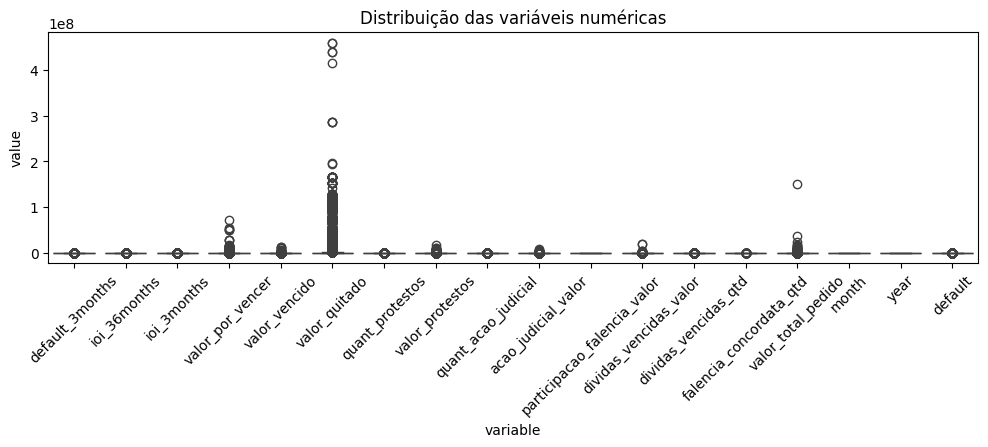

In [18]:
plt.figure(figsize = (12, 3))  # Define largura e altura da figura
df_longo = df.melt(value_vars = numeric_cols) # Converte o dataframe para formato longo para facilitar.
sns.boxplot(x = "variable", y = "value", data = df_longo)
plt.xticks(rotation = 45)
plt.title("Distribuição das variáveis numéricas")
plt.show()

### Histograma

In [ ]:
df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle("Histograma das Variáveis Numéricas", fontsize=16)
plt.show()


### Análise de Erros ou Características

In [ ]:
# Proporção de outliers por variável
outlier_proportion = outliers.sum() / len(df) * 100
print(outlier_proportion[outlier_proportion > 0].sort_values(ascending=False))

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrar somente os outliers
outlier_data = df[numeric_cols][(df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)]

# Estatísticas descritivas dos outliers
print(outlier_data.describe())

In [ ]:
#verificando 'Valor total (em Reais) de falências apresentadas pelo Serasa' 
df.participacao_falencia_valor.sum()

- analisar por que participacao_falencia_valor está completamente zerada

##### clientes possivelmente problemáticos

In [ ]:
# Definir os limites para clientes problemáticos
corte = 0.75
corte_protestos = df['quant_protestos'].quantile(corte)  # Exemplo: Top 25%
corte_acao_judicial = df['quant_acao_judicial'].quantile(corte)
corte_default_3months = df['default_3months'].quantile(corte)

# Filtrar clientes problemáticos
clientes_problemas = df[
    (df['quant_protestos'] >= corte_protestos) |
    (df['quant_acao_judicial'] >= corte_acao_judicial) |
    (df['default_3months'] >= corte_default_3months)
]

# Exibir uma amostra dos clientes problemáticos
print(clientes_problemas[['quant_protestos', 'quant_acao_judicial', 'default_3months']].head())


In [ ]:
# Estatísticas descritivas dos clientes problemáticos
stats_problemas = clientes_problemas.describe()
print(stats_problemas)

#### Valores muito altos

In [ ]:
# Definir os limites para valores altos
corte_valor_quitado = df['valor_quitado'].quantile(0.95)
corte_valor_vencido = df['valor_vencido'].quantile(0.95)
corte_quant_protestos = df['quant_protestos'].quantile(0.95)
corte_quant_acao_judicial = df['quant_acao_judicial'].quantile(0.95)

# Filtrar os clientes com valores extremamente altos
clientes_extremos = df[
    (df['valor_quitado'] >= corte_valor_quitado) |
    (df['valor_vencido'] >= corte_valor_vencido) |
    (df['quant_protestos'] >= corte_quant_protestos) |
    (df['quant_acao_judicial'] >= corte_quant_acao_judicial)
]

# Exibir uma amostra dos clientes filtrados
print(clientes_extremos[['valor_quitado', 'valor_vencido', 'quant_protestos', 'quant_acao_judicial']].head())


In [ ]:
# descritiva dos clientes extremos
print(clientes_extremos.describe())

In [ ]:
#Características adicionais dos clientes extremos

# Agrupar por setor de atividade principal
atividade_principal_extremos = clientes_extremos.groupby('atividade_principal').size().sort_values(ascending=False)
print("Distribuição por Atividade Principal:")
print(atividade_principal_extremos)

# Agrupar por tipo de sociedade
tipo_sociedade_extremos = clientes_extremos.groupby('tipo_sociedade').size().sort_values(ascending=False)
print("\nDistribuição por Tipo de Sociedade:")
print(tipo_sociedade_extremos)


### Segmentação de risco

In [ ]:
# DF para armazenar a segmentação de risco
segmentacao_risco = df.groupby(['atividade_principal', 'tipo_sociedade']).agg(
    taxa_inadimplencia=('default', 'mean'),
    total_clientes=('default', 'count'),
)

# Ordenar pela maior taxa de inadimplência
segmentacao_risco = segmentacao_risco.sort_values(by='taxa_inadimplencia', ascending=False)

# Exibir os segmentos com maior inadimplência
print(segmentacao_risco['taxa_inadimplencia'].head(20))

In [ ]:
# Função para plotar gráfico de análise bi-variada
def plot_bivariate_analysis(segmentacao_risco):
    plt.figure(figsize=(8, 4))
    top_activities = segmentacao_risco.groupby('atividade_principal')['taxa_inadimplencia'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=top_activities.index, y=top_activities.values, palette='coolwarm')
    plt.xticks(rotation=90)
    plt.xlabel('Atividade Principal')
    plt.ylabel('Taxa de Inadimplência Média')
    plt.title('Análise Bi-variada: Taxa de Inadimplência vs. Atividade Principal')
    plt.show()

# Chamada da função para visualização
top_activities = segmentacao_risco.groupby('atividade_principal')['taxa_inadimplencia'].mean().sort_values(ascending=False).head(10)
plot_bivariate_analysis(segmentacao_risco)

## Análise de Correlação

In [30]:
df_correlacao = df.copy()

In [31]:
FEATURES_NUMERICAS = df.select_dtypes(include=['number']).columns.tolist()
FEATURES_CATEGORICAS = df.select_dtypes(exclude=['number']).columns.tolist()
TODAS_FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS

In [ ]:
df_correlacao.columns.values

In [ ]:
# análise de campos em branco
df_correlacao[TODAS_FEATURES].isna().sum().sort_values(ascending=False)

In [34]:
#preenchendo valores vazios sem viés 
df_correlacao['forma_pagamento'].fillna("Desconhecido", inplace=True)
df_correlacao['opcao_tributaria'].fillna("Desconhecido", inplace=True)
df_correlacao['tipo_sociedade'].fillna("Desconhecido", inplace=True)
df_correlacao['atividade_principal'].fillna("Desconhecido", inplace=True)

In [ ]:
cores = ["#FFC0CB", "#e31c79", "#4B0023"]
correlation_heatmap(df_correlacao, cores=cores)

### WoE / IV

In [36]:
#calculando iv e woe
iv, woe = iv_woe(data = df_correlacao, target='default', bins=10, show_woe=False,show_iv=False)

#### WoE (Peso da Evidência)
- positivo: Indica que essa categoria tem uma maior proporção de eventos (default) do que de não eventos (pagamento em dia).
- negativo: Indica que essa categoria tem menos inadimplentes proporcionalmente.
- próximo de zero: A categoria tem uma distribuição equilibrada entre eventos e não eventos.

In [ ]:
woe.sort_values(by="WoE", ascending=False).head(20)

In [ ]:
woe.head()

#### IV
O cálculo de do IV é dado por

    | IV =   ∑ (% of non-events - % of events) * WOE

a interpretação do valor é dada pelo nível de relacionamento com Razão de Probabilidades da variável em questão e a variável resposta:

- \>= 0.02 : variável pode não ser útil na modelagem
- 0,02 < IV > = 0.1 : fraco
- 0.1 < IV >= 0.3 : médio
- 0.3 < IV >= 0.5 : forte
- \> 0.5 : informação suspeita, boa demais para ser real. Verificar com mais detalhes

In [ ]:
print('Variáveis com IV <= 0.02 devem ser descartadas')
display(iv.sort_values(by=['IV'], ascending=False).query("IV <= 0.02"))

In [ ]:
print('Variáveis com IV > 0.02')
display(iv.sort_values(by=['IV'], ascending=False).query("IV > 0.02"))

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Criando uma cópia do DataFrame original
df_encoded = df_correlacao.copy()

# Lista de variáveis categóricas
categorical_features = ['forma_pagamento', 'opcao_tributaria', 'tipo_sociedade']

# Aplicando Label Encoding
for col in categorical_features:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Lista de variáveis preditoras
features = ['forma_pagamento', 'opcao_tributaria', 'tipo_sociedade', 'valor_vencido', 'valor_quitado']

# Chamando a função de plot
plot_mi(database=df_encoded, features=features, target_variable=inadimplencia, n=10, figsize=(5, 3))

forma_pagamento, opcao_tributaria, tipo_sociedade são potencialmente preditivas

analisar  atividade_principal pelo WoE em algumas categorias

#### Agrupando variáveis forma_pagamento, opcao_tributaria, tipo_sociedade
##### forma_pagamento

In [ ]:
variavel_analise = 'forma_pagamento'
var_analise_agrup = f'{variavel_analise}_agrup'
#idenfificando o formato descrito em forma_pagamento para agrupar as categorias internas
df['forma_pagamento'].unique()

In [ ]:
len(df_correlacao[variavel_analise].unique())

In [ ]:
#agrupar por tipo de pagamento pode trazer benefícios
df_correlacao[var_analise_agrup] = agrupar_prazo(df_correlacao, variavel_analise)
print(df_correlacao[var_analise_agrup].value_counts())

In [ ]:
plot_distribuicao_bivariada(df=df_correlacao, variavel_analise=var_analise_agrup, nom_variavel_conceito=inadimplencia, taxa_evento=taxa_inadimplencia, figsize=(9,3))

##### tipo_sociedade

In [ ]:
variavel_analise = 'tipo_sociedade'
var_analise_agrup = f'{variavel_analise}_agrup'
df_correlacao[variavel_analise].unique()

In [ ]:
# Aplicar no DataFrame
df_correlacao[var_analise_agrup] = agrupar_tipo_sociedade(df, variavel_analise)

# Exibir as contagens
print(df_correlacao[var_analise_agrup].value_counts())

In [ ]:
plot_distribuicao_bivariada(df=df_correlacao, variavel_analise=var_analise_agrup, nom_variavel_conceito=inadimplencia, taxa_evento=taxa_inadimplencia, figsize=(9,3))

##### atividade_principal

In [ ]:
variavel_analise = 'atividade_principal'
var_analise_agrup = f'{variavel_analise}_agrup'
# Exibir as contagens
print(df_correlacao[variavel_analise].value_counts())

In [ ]:
# Aplicar no DataFrame
df_correlacao[var_analise_agrup] = agrupar_tipo_sociedade(df, variavel_analise)

# Exibir as contagens
print(df_correlacao[var_analise_agrup].value_counts())

In [ ]:
plot_distribuicao_bivariada(df=df_correlacao, variavel_analise=var_analise_agrup, nom_variavel_conceito=inadimplencia, taxa_evento=taxa_inadimplencia, figsize=(9,3))

##### opcao_tributaria

In [ ]:
variavel_analise = 'opcao_tributaria'
var_analise_agrup = f'{variavel_analise}_agrup'
# Exibir as contagens
print(df_correlacao[variavel_analise].value_counts())

In [ ]:
# Aplicar no DataFrame
df_correlacao[var_analise_agrup] = agrupar_opcao_tributaria(df, variavel_analise)

# Exibir as contagens
print(df_correlacao[var_analise_agrup].value_counts())

In [ ]:
plot_distribuicao_bivariada(df=df_correlacao, variavel_analise=var_analise_agrup, nom_variavel_conceito=inadimplencia, taxa_evento=taxa_inadimplencia, figsize=(9,3))

#### Qui-Quadrado (Chi-Square Test of Independence)
- Avalia se há relação entre duas categóricas
- teste principalmente para forma_pagamento, opcao_tributaria e tipo_sociedade

In [ ]:
var_alvo = 'forma_pagamento'
tabela_contingencia = pd.crosstab(df_correlacao[var_alvo], df_correlacao['default'])
chi2, p, dof, expected = chi2_contingency(tabela_contingencia)

print(f"Valor do Qui-Quadrado para {var_alvo}: {chi2}, p-valor: {p}")

In [ ]:
# Lista de variáveis categóricas
categorical_vars = ['forma_pagamento', 'opcao_tributaria', 'tipo_sociedade']

# Criar tabela com os valores de Qui-Quadrado e p-valor
chi2_results = []
for var in categorical_vars:
    contingency_table = pd.crosstab(df_correlacao[var], df_correlacao['default'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    chi2_results.append({'Variável': var, 'Qui-Quadrado': chi2, 'p-Valor': p})

# Criar DataFrame com os resultados
chi2_df = pd.DataFrame(chi2_results)


# Exibir a tabela
print("Tabela de Qui-Quadrado")
print(chi2_df)


In [ ]:
# Configuração geral dos gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Variáveis categóricas para análise
categorical_vars = ['forma_pagamento_agrupada', 'opcao_tributaria', 'tipo_sociedade']

# Criando gráficos de barras empilhadas para cada variável categórica
for i, var in enumerate(categorical_vars):
    sns.countplot(data=df_correlacao, x=var, hue='default', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribuição de {var} por Default')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Contagem')
    axes[i].tick_params(axis='x', rotation=45)

# Ajustar layout
plt.tight_layout()
plt.show()

## Análise bi-variada em gráficos

### Avaliando sazonalidade
A sazonalidade pode afetar a inadimplência

#### Ano
Avaliando se há alterações relevantes nas taxas nos anos descritos

In [ ]:
variavel_analise = 'year'
plot_distribuicao_bivariada(df, variavel_analise, 'default', taxa_inadimplencia, rotation=90, ha='center',show_line_labels=True, figsize=(9,3))

#### Mês
avaliando se há relação com o mês e a inadimplência

In [ ]:
variavel_analise = 'month'
df[variavel_analise] = df[variavel_analise].astype(str).str.zfill(2)
plot_distribuicao_bivariada(df, variavel_analise, 'default', taxa_inadimplencia, rotation=90, ha='center',show_line_labels=True, figsize=(9,3))

aparentemente nos meses iniciais do ano a inadimplência é maior

#### AnoMes

In [ ]:
# Criar a variável 'Anomes'  MMYYYY tipo str
df['anomes'] = (df['month'].astype(str).str.zfill(2) + df['year'].astype(str)).astype(str)

# Exibir as primeiras linhas para conferir
df[['month', 'year', 'anomes']].head()

In [ ]:
variavel_analise = 'anomes'
plot_distribuicao_bivariada(df, variavel_analise, 'default', taxa_inadimplencia, rotation=90, ha='center',show_line_labels=True)

## Outras análises

In [ ]:
print("Os anos dos pedidos na base são")
df.year.unique()

In [ ]:
print('Media de inadimplência nos anos: ')
df.groupby('year')[inadimplencia].mean()